In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(der_K.shape[0], 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        return 0.5 * jnp.sum(self.K * del_strain**2) + self.mlp(del_strain)


validate_model(Example)
final_model, train_history, valid_history = train_model(Example)

train.qs shape:  (11, 11)
valid.qs shape:  (11, 11)
Step 0    | Train: 2.12837e-04  | Valid: 2.01264e-04 
Step 10   | Train: 1.46500e-04  | Valid: 1.29906e-04 
Step 20   | Train: 1.69857e-04  | Valid: 1.85529e-04 
Step 30   | Train: 7.57122e-05  | Valid: 6.72729e-05 
Step 40   | Train: 1.20344e-05  | Valid: 9.10628e-06 
Step 50   | Train: 3.15841e-06  | Valid: 2.65380e-06 
Step 60   | Train: 2.57774e-06  | Valid: 3.36939e-06 
Step 70   | Train: 2.07387e-06  | Valid: 3.19567e-06 
Step 80   | Train: 2.23088e-06  | Valid: 3.28406e-06 
Step 90   | Train: 1.93233e-06  | Valid: 2.79151e-06 
Step 100  | Train: 1.81077e-06  | Valid: 2.51155e-06 


Text(0.5, 1.0, 'Training and Validation Loss')

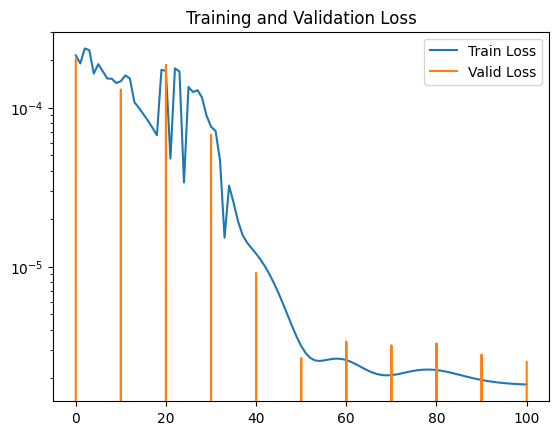

In [2]:
import matplotlib.pyplot as plt
plt.plot(train_history, label="Train Loss")
plt.plot(valid_history, label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.title("Training and Validation Loss")

In [3]:
from util import TestCase

valid = TestCase.from_npz("valid.npz")
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [4]:
animate(valid.qs)

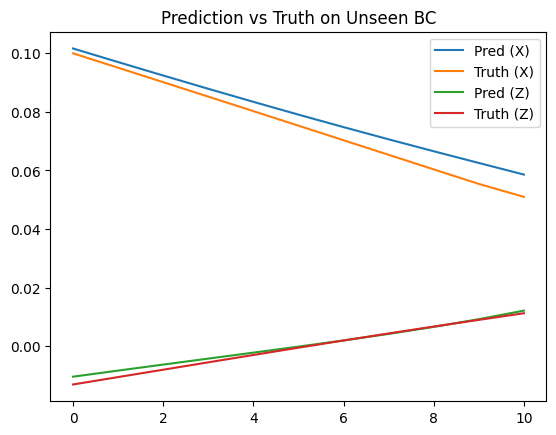

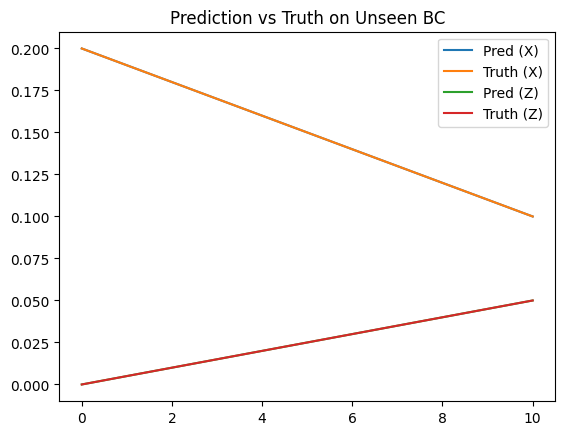

In [5]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.show()

# moved end node
plt.plot(pred[:, 8], label="Pred (X)")
plt.plot(valid.qs[:, 8], label="Truth (X)")
# plt.plot(pred[:, 9], label="Pred (Y)")
# plt.plot(valid.qs[:, 9], label="Truth (Y)")
plt.plot(pred[:, 10], label="Pred (Z)")
plt.plot(valid.qs[:, 10], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.show()

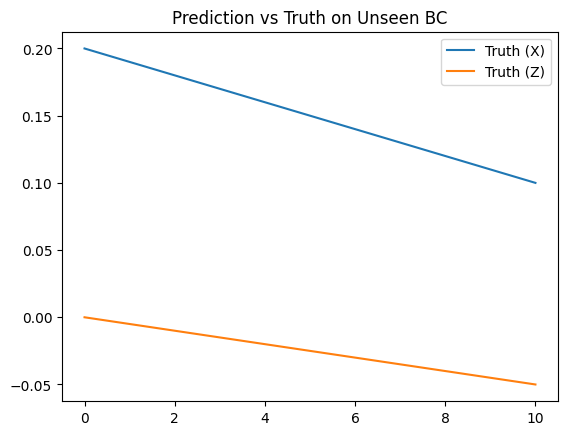

In [6]:
# moved end node in training
train =  TestCase.from_npz("train.npz")
plt.plot(train.qs[:, 8], label="Truth (X)")
# plt.plot(valid.qs[:, 9], label="Truth (Y)")
plt.plot(train.qs[:, 10], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.show()

In [7]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.2 0.  0. ]
final:  [ 0.1   0.   -0.05]
Validation BC:
init:  [0.2 0.  0. ]
final:  [0.1  0.   0.05]


In [8]:
class DER2D(eqx.Module):
    # DER2D for smaller K

    K: jax.Array  # [EA1, EA2, EI]

    @classmethod
    def from_legacy(cls, l_k: jax.Array, geom: djx.Geometry, material: djx.Material):
        A = geom.axs if geom.axs else jnp.pi * geom.r0**2
        EA = material.youngs_rod * A

        if geom.ixs1 and geom.ixs2:
            EI2 = material.youngs_rod * geom.ixs2
        else:
            EI2 = material.youngs_rod * jnp.pi * geom.r0**4 / 4

        # TODO: what is proper name
        something = geom.jxs if geom.jxs else jnp.pi * geom.r0**4 / 2
        GJ = material.youngs_rod / (2 * (1 + material.poisson_rod)) * something

        # Rescale
        EA *= l_k
        EI2 /= l_k

        return cls(jnp.array([EA, EA, EI2]))

    def __call__(self, del_strain: jax.Array) -> jax.Array:
        return jnp.sum(self.K * del_strain**2)


# Example init
geom = djx.Geometry(0.2, 5e-3)
mat = djx.Material(1273.52, 1e7)
base, _ = djx.Rod.from_geometry(geom, mat, N=3, is_2d=True)
der2d = DER2D.from_legacy(base.triplets.l_k[0, 0], geom, mat)

# Static BC
bc = djx.LinearBC(
    idx_b=jnp.array([0, 1, 2, 3, 7, 8, 9, 10]),
    xb_m=jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
    xb_c=jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0]),
)
rod = base.with_bc(bc)
term = rod.get_ode_term()

lambdas = jnp.linspace(0.0, 1.0, 500)
y0 = jnp.concatenate([rod.q0, jnp.zeros_like(rod.q0)])
out = diffrax.diffeqsolve(
    term,
    diffrax.Dopri5(),
    0.0,
    1.0,
    1e-3,
    y0,
    args=(der2d, aux),
    saveat=diffrax.SaveAt(ts=lambdas),
)

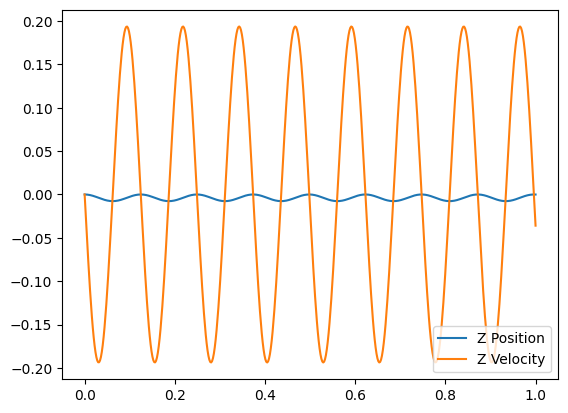

In [9]:
import matplotlib.pyplot as plt

plt.plot(lambdas, out.ys[:, 6], label="Z Position")
plt.plot(lambdas, out.ys[:, 17], label="Z Velocity")
plt.legend()
plt.show()